# To do for Key Accuracy

- [ ] Implement alternative key calling methods: random guess, educated guess, correlation guess.
- [ ] Compare results with same window size (infered or parametric)

In [1]:
using DelimitedFiles
using Distances
using FileIO
using DataFrames
using LinearAlgebra
using Random
using StatsBase
using Statistics
using CSV
using PlotlyJS

In [2]:
using PyCall
m21 = pyimport("music21")
np = pyimport("numpy")

PyObject <module 'numpy' from '/home/alfredo/.local/lib/python3.12/site-packages/numpy/__init__.py'>

In [3]:
# new version of MusicSpiralRepresentation
const msr2 = include("../MSRv2/MusicSpiralRepresentation.jl")

Main.MusicSpiralRepresentationv2

In [4]:
# my packages and tools (utils)
#using MusicSpiralRepresentation
#const msr = MusicSpiralRepresentation
#const srt = include("Utils.jl")
const srt = include("../msr2_utils.jl")

Main.msr2_utils

In [5]:
function get_key_lims(piece_ann)
    local lk
    try
        lk = piece_ann[!, :local_key]
    catch
        lk = piece_ann[!, :localkey]
    end
    lims = Int64[]
    for i in 2:length(lk)
        if lk[i-1] != lk[i]
            push!(lims, i)
        end
    end

    # Get the quarterbeats values
    quarterbeats_strings = piece_ann[lims, :quarterbeats]

    # Convert strings to real numbers
    quarterbeats_real = Float64[]
    for qb_str in quarterbeats_strings
        if contains(string(qb_str), "/")
            # Handle fraction strings like "11/2"
            parts = split(string(qb_str), "/")
            numerator = parse(Float64, parts[1])
            denominator = parse(Float64, parts[2])
            push!(quarterbeats_real, numerator / denominator)
        else
            # Handle integer strings like "10"
            push!(quarterbeats_real, parse(Float64, string(qb_str)))
        end
    end

    return quarterbeats_real
end

get_key_lims (generic function with 1 method)

In [6]:
"""
Krumhansl-Schmuckler Key-Finding Algorithm Implementation
"""

using Statistics

# Key profiles from Krumhansl & Kessler (1982)
const MAJOR_PROFILE = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
const MINOR_PROFILE = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]

# Key names in chromatic order (pitch class 0-11)
const MAJOR_KEY_NAMES = ["C", "Db/C#", "D", "Eb", "E", "F", "Gb/F#", "G", "Ab", "A", "Bb", "B/Cb"]
const MINOR_KEY_NAMES = ["c", "c#", "d", "eb", "e", "f", "f#", "g", "g#/ab", "a", "bb", "b"]

"""
    krumhansl_schmuckler(midi_notes::Vector{Int}; sorted::Bool=false) -> NamedTuple

Find musical key from MIDI note numbers with equal weighting.

# Arguments
- `midi_notes::Vector{Int}`: Array of MIDI note numbers (0-127)
- `sorted::Bool=false`: If true, sort results by correlation (highest to lowest)

# Returns
NamedTuple containing:
- `correlations`: Array of (key, correlation) tuples for all 24 keys
- `best_key`: Most likely key name
- `best_correlation`: Correlation value of best key
- `pitch_class_distribution`: The computed pitch class vector
"""
function krumhansl_schmuckler(midi_notes::Vector{Int}; sorted::Bool=false)
    pitch_class_counts = zeros(Float64, 12)
    for note in midi_notes
        pitch_class = mod(note, 12)
        pitch_class_counts[pitch_class+1] += 1.0
    end

    return _compute_key_correlations(pitch_class_counts, sorted)
end

"""
    krumhansl_schmuckler(midi_notes::Vector{Int}, weights::Vector{<:Real}; sorted::Bool=false) -> NamedTuple

Find musical key from MIDI notes with associated weights.

# Arguments
- `midi_notes::Vector{Int}`: Array of MIDI note numbers (0-127)
- `weights::Vector{<:Real}`: Array of weights (same length as midi_notes)
- `sorted::Bool=false`: If true, sort results by correlation (highest to lowest)

# Returns
Same as unweighted version.
"""
function krumhansl_schmuckler(midi_notes::Vector{Int}, weights::Vector{<:Real}; sorted::Bool=false)
    if length(midi_notes) != length(weights)
        throw(ArgumentError("midi_notes and weights must have the same length"))
    end

    pitch_class_counts = zeros(Float64, 12)
    for (note, weight) in zip(midi_notes, weights)
        pitch_class = mod(note, 12)
        pitch_class_counts[pitch_class+1] += Float64(weight)
    end

    return _compute_key_correlations(pitch_class_counts, sorted)
end

"""
    _compute_key_correlations(pitch_class_counts::Vector{Float64}, sorted::Bool) -> NamedTuple

Internal function to compute correlations for all 24 keys.
"""
function _compute_key_correlations(pitch_class_counts::Vector{Float64}, sorted::Bool)
    correlations = []

    # Calculate correlations for all keys in chromatic order
    for pitch_class in 0:11
        idx = pitch_class + 1

        # Major key
        shifted_profile = circshift(MAJOR_PROFILE, pitch_class)
        corr_major = cor(pitch_class_counts, shifted_profile)
        push!(correlations, (key=MAJOR_KEY_NAMES[idx], correlation=corr_major))

        # Minor key
        shifted_profile = circshift(MINOR_PROFILE, pitch_class)
        corr_minor = cor(pitch_class_counts, shifted_profile)
        push!(correlations, (key=MINOR_KEY_NAMES[idx], correlation=corr_minor))
    end

    # Sort if requested
    if sorted
        correlations = sort(correlations, by=x -> x.correlation, rev=true)
    end

    # Find best key
    best = argmax([c.correlation for c in correlations])

    return (
        correlations=correlations,
        best_key=correlations[best].key,
        best_correlation=correlations[best].correlation,
        pitch_class_distribution=pitch_class_counts
    )
end

_compute_key_correlations

# Ground-truth annotations

In [7]:
moz_ann_path = "/home/alfredo/Datasets/DCML_Corpora/mozart_piano_sonatas-main/harmonies" #annotated data
moz_ann_list = readdir(moz_ann_path)
moz_ann_list = filter(x -> occursin(r"\.tsv$", x), moz_ann_list)
moz_ann_names = map(x -> split(x, ".")[1], moz_ann_list)
moz_piece_ann = map(x -> CSV.read(joinpath(moz_ann_path, moz_ann_list[x]), DataFrame, delim='\t', header=true), 1:length(moz_ann_list));

# Scores

In [8]:
mozart_folder = "/home/alfredo/Datasets/DCML_Corpora/mozart_piano_sonatas-main/notes/"
mozart_list = readdir(mozart_folder)
mozart_list = filter(x -> endswith(x, ".tsv"), mozart_list);

In [9]:
#saving names 
#bee_names = map(x -> split(x, ".")[1], bee_list);
mozart_names = map(x -> split(x, ".")[1], mozart_list);

In [10]:
moz_dfs = DataFrame[]
good_ix = Int64[]
for i in 1:length(mozart_list)
    try
        tsv_piece = CSV.read(joinpath(mozart_folder, mozart_list[i]), DataFrame, delim='\t', header=true)
        df_piece = srt.process_tsv_score(tsv_piece, repeats=true)
        push!(moz_dfs, df_piece)
        push!(good_ix, i)
    catch e
        println("Error processing $i: $e")
    end
end

In [11]:
function get_key_accuracy_by_window_KS(df_piece, piece_ann; w_s=20, return_keys=false, mean_center=true)
    mc_ann = groupby(piece_ann, :mc)
    ann_k_measures = Dict{Int,Any}()
    for i in 1:length(mc_ann)
        ann_k_measures[mc_ann[i][1, :mc]] = mc_ann[i][!, :localkey][1]
    end
    # divide the piece into overlapping windows of size w_s with an overlap of w_s-1
    w_piece = srt.get_oswindows(df_piece, w_s, w_s - 1)
    p_keys = Vector{String}(undef, length(w_piece))

    #computing the most likely key using the Krumhansl-Schmuckler algorithm for each window
    for i in 1:length(w_piece)
        p_keys[i] = krumhansl_schmuckler(w_piece[i][!, :Pitch], w_piece[i][!, :Duration], sorted=true)[2]
    end
    # defining the main key as the most frequent and getting the relative keys
    main_key = msr2.get_rank_freq(p_keys)[1, 1]
    rel_keys = msr2.funhar_seq(p_keys, main_key)
    ce_ix = zeros(Int64, length(rel_keys))
    ann_keys = Array{Any}(undef, length(rel_keys))
    for i in 1:length(rel_keys)
        if mean_center
            ce_ix[i] = Int(round(mean(w_piece[i][!, :Measure])))
        else
            # Get center row of window
            center_row_idx = div(nrow(w_piece[i]), 2) + 1
            # Get quarterbeat at center (using start of center note)
            center_qb = w_piece[i][center_row_idx, :StartQuarter]
            # Find which measure contains this quarterbeat
            measure_idx = findfirst(row -> row.StartQuarter <= center_qb <= row.EndQuarter, eachrow(df_piece))
            ce_ix[i] = df_piece[measure_idx, :Measure]
        end
        try
            ann_keys[i] = Array(piece_ann[findall(x -> x == ce_ix[i], piece_ann[!, :mc]), :localkey])
        catch
            ann_keys[i] = String(piece_ann[findall(x -> x == ce_ix[i], piece_ann[!, :mc]), :localkey])
        end
    end

    u_measures = unique(ce_ix)
    guess_k_measures = Dict{Int,Any}()
    for uv in u_measures
        ix = findall(x -> x == uv, ce_ix)
        guess_k_measures[uv] = msr2.get_rank_freq(rel_keys[ix])[1, 1]
    end
    # calculating the accuracy of the key prediction
    tot_measures = 0
    correct_measures = 0
    for key in keys(ann_k_measures)
        if haskey(guess_k_measures, key)
            tot_measures += 1
            if ann_k_measures[key] == guess_k_measures[key]
                correct_measures += 1
            end
        end
    end
    if return_keys
        return tot_measures, correct_measures, correct_measures / tot_measures, rel_keys
    else
        return tot_measures, correct_measures, correct_measures / tot_measures
    end
end

get_key_accuracy_by_window_KS (generic function with 1 method)


# Accuracy by window - regional

* Is the accuracy defined by the center of effect within a span of notes (w_s), that is centered in the measure of referrence
* Key can be estimated with a window of > 1 measure bar (4 quarters for regular measure), but it is centered at a particular measure of referrence
* Guessed keys are compared with the "local key" annotation only, which refers to the relative numeral to the fundamental key (main key of the piece)

In [12]:
function plot_accuracy(wrange, accs; title="Key Accuracy vs Window Size",
    xlabel="Window Size (Quarter Beats)",
    ylabel="Accuracy",
    marker_size=8,
    marker_color="blue")

    scatter(
        x=collect(wrange),
        y=accs,
        mode="markers",
        marker=attr(
            size=marker_size,
            color=marker_color,
            opacity=0.7,
            line=attr(width=1, color="darkblue")
        ),
        name="Accuracy",
        text=["Window: $(w), Acc: $(round(a, digits=3))" for (w, a) in zip(wrange, accs)],
        hovertemplate="Window Size: %{x}<br>Accuracy: %{y}<br><extra></extra>"
    ) |> plot |> x -> relayout(x,
        title=title,
        xaxis_title=xlabel,
        yaxis_title=ylabel,
        showlegend=false,
        hovermode="closest"
    )
end


plot_accuracy (generic function with 1 method)

In [13]:
function get_accuracy_table(piece_df, piece_ann; sorted=true)
    st_qb = Int(2 * srt.to_quarters(piece_df[1, :TimeSignature]))
    stp = Int(srt.to_quarters(piece_df[1, :TimeSignature]))
    end_qb = Int(round(piece_df[end, :EndQuarter] / 3, digits=0))
    wrange = st_qb:stp:end_qb
    accs = Float64[]
    for w_s in wrange
        _,_,acc = srt.get_key_accuracy_by_window(piece_df, piece_ann; w_s=w_s, mean_center=true)
        push!(accs, acc)
    end
    if sorted == false
        out_df = DataFrame(Window=wrange, Accuracy=accs)
    else
        ix_ord = sortperm(accs, rev=true)
        out_df = DataFrame(Window=wrange[ix_ord], Accuracy=accs[ix_ord])
    end
    return out_df
end         

get_accuracy_table (generic function with 1 method)

In [14]:
using KernelDensity
function plot_kde_distribution(data; title="Distribution", xlabel="Values", ylabel="Density",
    color="blue", fill_alpha=0.3, line_width=2, size=(800, 600))

    # Compute KDE
    kde_result = kde(data)

    # Create the plot
    plot(
        scatter(
            x=kde_result.x,
            y=kde_result.density,
            mode="lines",
            fill="tozeroy",
            fillcolor="rgba(0,100,200,$(fill_alpha))",
            line=attr(
                color=color,
                width=line_width
            ),
            name="KDE",
            hovertemplate="Value: %{x}<br>Density: %{y}<extra></extra>"
        ),
        Layout(
            title=title,
            xaxis_title=xlabel,
            yaxis_title=ylabel,
            showlegend=false,
            width=size[1],
            height=size[2]
        )
    )
end

plot_kde_distribution (generic function with 1 method)

# Computing best window size for key guessing

The heuristic we follow to compute accuracy with a parameter `w_s` is:
    
    1) Define a window range from 2 times the size of the measure, incrementing the size by a number of quarters equivalent to a measure, ending with a window of 1/3 of size of the original piece (in quarterbeats)
    2) For each window size, compute the most likely key, defined by our algorithm and save it
    3) Get the maximum accuracy reached by the sliding window experiment, save the value and the window size

# Computing window accuracy with a fixed window size of 1/10 of the length of the piece in quarterbeats

In [22]:
moz_accs = Float64[]
for i in 1:length(moz_dfs)
    #nquarters = maximum(moz_dfs[i][!, :EndQuarter])
    ws = 50
    _,_, acc, _ = srt.get_key_accuracy_by_window(moz_dfs[i], moz_piece_ann[i]; w_s=ws, return_keys=true)
    push!(moz_accs, acc)
end

In [23]:
ks_accs = Float64[]
for np in 1:length(moz_dfs)
    try
       # nquarters = maximum(moz_dfs[np][!, :EndQuarter])
        ws = 50
        ks_acc = get_key_accuracy_by_window_KS(moz_dfs[np], moz_piece_ann[np], w_s=ws, return_keys=false, mean_center=true)[3]
        push!(ks_accs, ks_acc)
    catch e
        println("Error processing window $np: $e")
    end
end

Error processing window 41: MethodError(-, (nothing, 1), 0x0000000000006aae)


In [26]:
using Statistics 

In [31]:
moz_acc2 = deleteat!(copy(moz_accs), 41)

53-element Vector{Float64}:
 0.8313253012048193
 0.17857142857142858
 0.8888888888888888
 0.8728813559322034
 0.36363636363636365
 0.8161764705882353
 0.9176470588235294
 0.16393442622950818
 0.863013698630137
 0.13043478260869565
 ⋮
 0.05084745762711865
 0.8245614035087719
 0.0
 0.7707006369426752
 0.7272727272727273
 0.8311688311688312
 0.7213114754098361
 0.6862745098039216
 0.7070063694267515

In [32]:
cor(moz_acc2, ks_accs)

0.841415720298705

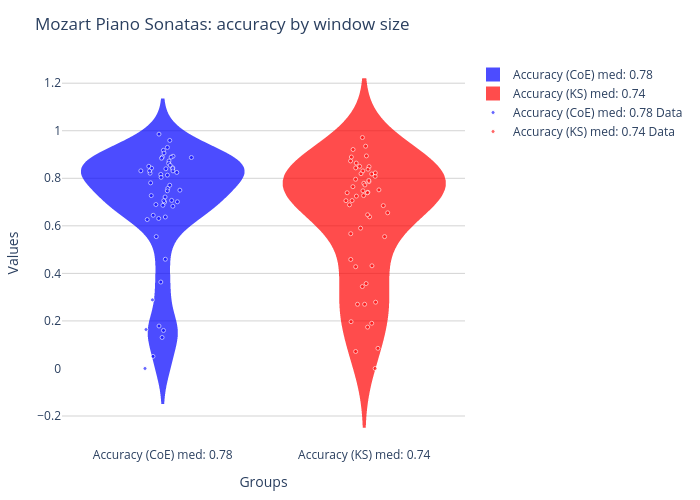

In [25]:
fig = srt.plot_violin_scatter(moz_accs, ks_accs, title="Mozart Piano Sonatas: accuracy by window size", labels=["Accuracy (CoE) med: $(round(median(moz_accs), digits=2))", "Accuracy (KS) med: $(round(median(ks_accs), digits=2))"])

In [33]:
PlotlyJS.savefig(fig, "Mozart_Key_Acc_Window_50.png")

"Mozart_Key_Acc_Window_50.png"

In [15]:
piece_accs = []
good_ix = Int64[]
for np in 1:length(moz_dfs)
    try
        println("Processing piece $np / $(length(moz_dfs))")
        key_acc = get_accuracy_table(moz_dfs[np], moz_piece_ann[np], sorted=false);
        push!(piece_accs, key_acc)
        push!(good_ix, np)
    catch e
        println("Error processing piece $np: $e")
    end
end

Processing piece 1 / 54
Processing piece 2 / 54
Processing piece 3 / 54
Processing piece 4 / 54
Processing piece 5 / 54
Processing piece 6 / 54
Error processing piece 6: InexactError(:Int64, (Int64, 1.5))
Processing piece 7 / 54
Processing piece 8 / 54
Error processing piece 8: InexactError(:Int64, (Int64, 1.5))
Processing piece 9 / 54
Processing piece 10 / 54
Processing piece 11 / 54
Processing piece 12 / 54
Processing piece 13 / 54
Processing piece 14 / 54
Processing piece 15 / 54
Error processing piece 15: InexactError(:Int64, (Int64, 1.5))
Processing piece 16 / 54
Processing piece 17 / 54
Processing piece 18 / 54
Processing piece 19 / 54
Processing piece 20 / 54
Processing piece 21 / 54
Processing piece 22 / 54
Processing piece 23 / 54
Processing piece 24 / 54
Processing piece 25 / 54
Processing piece 26 / 54
Processing piece 27 / 54
Processing piece 28 / 54
Processing piece 29 / 54
Processing piece 30 / 54
Processing piece 31 / 54
Processing piece 32 / 54
Processing piece 33 / 54


In [16]:
moz_accs = Float64[]
moz_ws = Float64[]
moz_wsn = Int64[]
for np in 1:length(piece_accs)
    ix = findmax(piece_accs[np][!,:Accuracy])[2]
    push!(moz_accs, piece_accs[np][ix, :Accuracy])
    wsn = piece_accs[np][ix, :Window]
    ws = wsn / moz_dfs[good_ix[np]][end, :EndQuarter]
    push!(moz_ws, ws)
    push!(moz_wsn, wsn)
end

In [21]:
print("mean: $(mean(moz_wsn)), median:$(median(moz_wsn))")

mean: 60.35294117647059, median:50.0

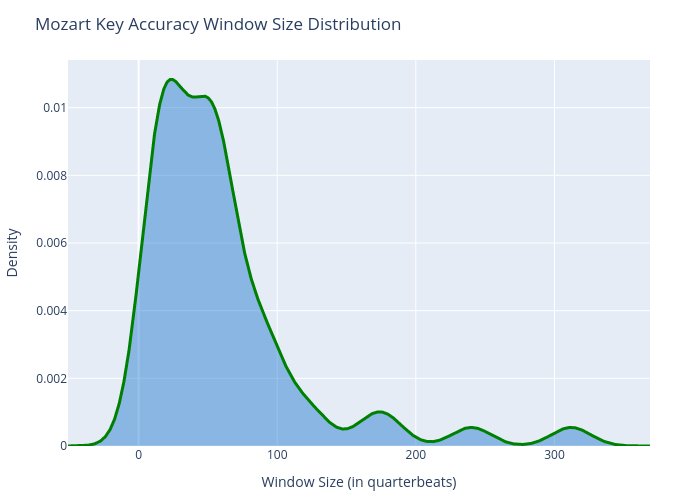

In [34]:
plot_kde_distribution(moz_wsn; title="Mozart Key Accuracy Window Size Distribution",
    xlabel="Window Size (in quarterbeats)",
    ylabel="Density",
    color="green",
    fill_alpha=0.4,
    line_width=3,
    size=(800,600)
    )

In [ ]:
ks_accs = Float64[]
for np in good_ix
    try
        ks_acc = get_key_accuracy_by_window_KS(moz_dfs[np], moz_piece_ann[np], w_s=moz_wsn[good_ix[np]], return_keys=false, mean_center=true)[3]
        push!(ks_accs, ks_acc)
    catch e
        println("Error processing window $np: $e")
    end
end

Error processing window 9: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 10: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 40: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 41: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 42: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 44: MethodError(-, (nothing, 1), 0x0000000000006a7d)
Error processing window 49: BoundsError([128, 21, 88, 69, 24, 18, 92, 16, 12, 28, 6, 8, 116, 21, 80, 56, 15, 60, 64, 51, 50, 56, 40, 33, 34, 42, 50, 21, 39, 26, 87, 52, 54, 180, 48, 60, 240, 20, 312, 168, 102, 48, 8, 12, 14, 63, 16, 56, 66, 18, 90], (52,))
Error processing window 50: BoundsError([128, 21, 88, 69, 24, 18, 92, 16, 12, 28, 6, 8, 116, 21, 80, 56, 15, 60, 64, 51, 50, 56, 40, 33, 34, 42, 50, 21, 39, 26, 87, 52, 54, 180, 48, 60, 240, 20, 312, 168, 102, 48, 8, 12, 14, 63, 16, 56, 66, 18, 90], (53,))
Error processing window 5

In [17]:
filter!(x -> x>0, ks_accs)

38-element Vector{Float64}:
 0.8615384615384616
 0.6923076923076923
 0.7850467289719626
 0.8928571428571429
 0.5
 0.7788461538461539
 0.7272727272727273
 0.15730337078651685
 0.25773195876288657
 0.8918918918918919
 ⋮
 0.4166666666666667
 0.058823529411764705
 0.8907563025210085
 0.7021276595744681
 0.72
 0.24056603773584906
 0.8630952380952381
 0.05555555555555555
 0.8260869565217391

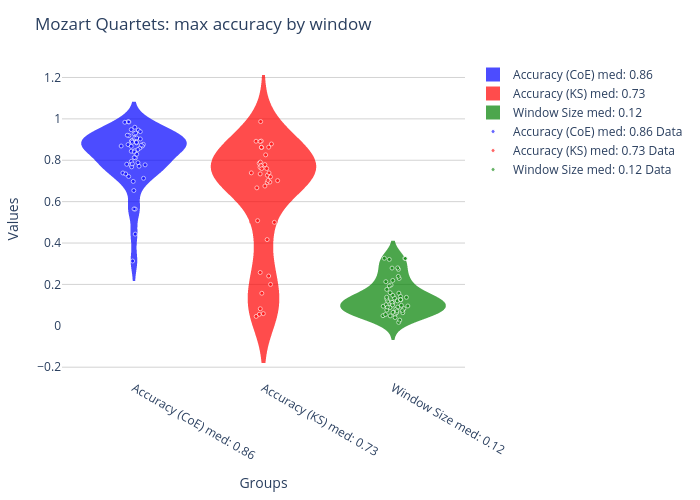

In [18]:
fig = srt.plot_violin_scatter(moz_accs, ks_accs, moz_ws, title="Mozart Quartets: max accuracy by window", labels=["Accuracy (CoE) med: $(round(median(moz_accs), digits=2))","Accuracy (KS) med: $(round(median(ks_accs), digits=2))" ,"Window Size med: $(round(median(moz_ws), digits=2))"])

In [11]:
bee_ann_path = "/home/alfredo/Datasets/DCML_Corpora/ABC-2f12c12ab57ace9fb8d94b5f49ab1d7cca5db3dd/harmonies" #annotated data
bee_ann_list = readdir(bee_ann_path)
bee_ann_list = filter(x -> occursin(r"\.tsv$", x), bee_ann_list)
bee_ann_names = map(x -> split(x, ".")[1], bee_ann_list)
bee_piece_ann = map(x -> CSV.read(joinpath(bee_ann_path, bee_ann_list[x]), DataFrame, delim='\t', header=true), 1:length(bee_ann_list));

In [12]:
bee_folder = "/home/alfredo/Datasets/DCML_Corpora/ABC-2f12c12ab57ace9fb8d94b5f49ab1d7cca5db3dd/notes"
bee_list = readdir(bee_folder)
bee_list = filter(x -> endswith(x, ".tsv"), bee_list);

In [13]:
bee_dfs = DataFrame[]
good_ixbe = Int64[]
for i in 1:length(bee_list)
    try
        tsv_piece = CSV.read(joinpath(bee_folder, bee_list[i]), DataFrame, delim='\t', header=true)
        df_piece = srt.process_tsv_score(tsv_piece, repeats=true)
        push!(bee_dfs, df_piece)
        push!(good_ixbe, i)
    catch e
        println("Error processing $i: $e")
    end
end

In [14]:
bee_accs = Float64[]
for i in 1:length(bee_dfs)
    nquarters = maximum(bee_dfs[i][!, :EndQuarter])
    ws = Int(round(nquarters * 0.10))
    _, _, acc, _ = srt.get_key_accuracy_by_window(bee_dfs[i], bee_piece_ann[i]; w_s=ws, return_keys=true)
    push!(bee_accs, acc)
end

In [17]:
filter!(x -> x >0, bee_accs)

65-element Vector{Float64}:
 0.5434782608695652
 0.5208333333333334
 0.28846153846153844
 0.3961038961038961
 0.13333333333333333
 0.7466666666666667
 0.46308724832214765
 0.49767441860465117
 0.6220472440944882
 0.75177304964539
 ⋮
 0.4542372881355932
 0.5276381909547738
 0.75
 0.6
 0.6109422492401215
 0.5364238410596026
 0.5449101796407185
 0.5510204081632653
 0.4089068825910931

In [16]:
ks_bee_accs = Float64[]
for np in 1:length(bee_dfs)
    try
        nquarters = maximum(bee_dfs[np][!, :EndQuarter])
        ws = Int(round(nquarters * 0.10))
        ks_acc = get_key_accuracy_by_window_KS(bee_dfs[np], bee_piece_ann[np], w_s=ws, return_keys=false, mean_center=true)[3]
        push!(ks_bee_accs, ks_acc)
    catch e
        println("Error processing window $np: $e")
    end
end

Error processing window 22: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 24: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 29: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 44: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 46: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 47: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 50: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 51: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 53: MethodError(-, (nothing, 1), 0x0000000000006aad)
Error processing window 55: MethodError(-, (nothing, 1), 0x0000000000006aad)


In [18]:
filter!(x -> x>0, ks_bee_accs)

59-element Vector{Float64}:
 0.30434782608695654
 0.4375
 0.22115384615384615
 0.2824675324675325
 0.3238095238095238
 0.6533333333333333
 0.5063291139240507
 0.35570469798657717
 0.5395348837209303
 0.5433070866141733
 ⋮
 0.30042918454935624
 0.5527638190954773
 0.7959183673469388
 0.4857142857142857
 0.270516717325228
 0.5033112582781457
 0.31736526946107785
 0.4897959183673469
 0.3481781376518219

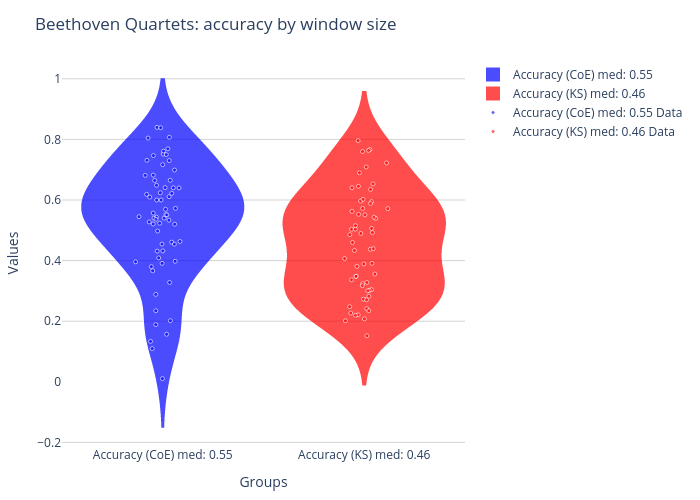

In [20]:
fig = srt.plot_violin_scatter(bee_accs, ks_bee_accs, title="Beethoven Quartets: accuracy by window size", labels=["Accuracy (CoE) med: $(round(median(bee_accs), digits=2))", "Accuracy (KS) med: $(round(median(ks_bee_accs), digits=2))"])

In [21]:
PlotlyJS.savefig(fig, "Beethoven_Key_Acc_Window.png")

"Beethoven_Key_Acc_Window.png"

In [13]:
piece_accs = []
good_ix = Int64[]
for np in 1:length(bee_dfs)
    try
        println("Processing piece $np / $(length(bee_dfs))")
        key_acc = get_accuracy_table(bee_dfs[np], bee_piece_ann[np], sorted=false)
        push!(piece_accs, key_acc)
        push!(good_ix, np)
    catch e
        println("Error processing piece $np: $e")
    end
end

Processing piece 1 / 70
Processing piece 2 / 70
Error processing piece 2: InexactError(:Int64, (Int64, 4.5))
Processing piece 3 / 70
Processing piece 4 / 70
Processing piece 5 / 70
Processing piece 6 / 70
Processing piece 7 / 70
Processing piece 8 / 70
Processing piece 9 / 70
Processing piece 10 / 70
Processing piece 11 / 70
Processing piece 12 / 70
Processing piece 13 / 70
Processing piece 14 / 70
Error processing piece 14: InexactError(:Int64, (Int64, 1.5))
Processing piece 15 / 70
Processing piece 16 / 70
Processing piece 17 / 70
Processing piece 18 / 70
Processing piece 19 / 70
Processing piece 20 / 70
Processing piece 21 / 70
Processing piece 22 / 70
Processing piece 23 / 70
Processing piece 24 / 70
Processing piece 25 / 70
Processing piece 26 / 70
Error processing piece 26: InexactError(:Int64, (Int64, 1.5))
Processing piece 27 / 70
Processing piece 28 / 70
Processing piece 29 / 70
Processing piece 30 / 70
Processing piece 31 / 70
Processing piece 32 / 70
Processing piece 33 / 70

In [14]:
bee_accs = Float64[]
bee_ws = Float64[]
bee_wsn = Int64[]
for np in 1:length(piece_accs)
    ix = findmax(piece_accs[np][!, :Accuracy])[2]
    push!(bee_accs, piece_accs[np][ix, :Accuracy])
    wsn = piece_accs[np][ix, :Window]
    ws = wsn / bee_dfs[good_ix[np]][end, :EndQuarter]
    push!(bee_ws, ws)
    push!(bee_wsn, wsn)
end

In [22]:
get_key_accuracy_by_window_KS(bee_dfs[1], bee_piece_ann[1], w_s=bee_wsn[good_ix[1]], return_keys=false, mean_center=true)

(222, 62, 0.27927927927927926)

In [23]:
ks_bee_accs = Float64[]
for np in good_ix
    try
        ks_acc = get_key_accuracy_by_window_KS(bee_dfs[np], bee_piece_ann[np], w_s=bee_wsn[good_ix[np]], return_keys=false, mean_center=true)[3]
        push!(ks_bee_accs, ks_acc)
    catch e
        println("Error processing window $np: $e")
    end
end

Error processing window 12: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 29: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 37: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 39: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 42: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 44: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 46: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 47: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 50: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 54: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 55: MethodError(-, (nothing, 1), 0x0000000000006a7f)
Error processing window 57: BoundsError(Matrix{Any}(undef, 0, 2), (1, 1))
Error processing window 60: BoundsError(Matrix{Any}(undef, 0, 2), (1, 1))
Error

In [25]:
filter!(x-> x>0, ks_bee_accs)

41-element Vector{Float64}:
 0.27927927927927926
 0.14678899082568808
 0.26865671641791045
 0.2815533980582524
 0.68
 0.47692307692307695
 0.4625
 0.48826291079812206
 0.2
 0.7479674796747967
 ⋮
 0.42105263157894735
 0.7573221757322176
 0.46774193548387094
 0.3735632183908046
 0.42028985507246375
 1.0
 0.54375
 0.51171875
 0.5662983425414365

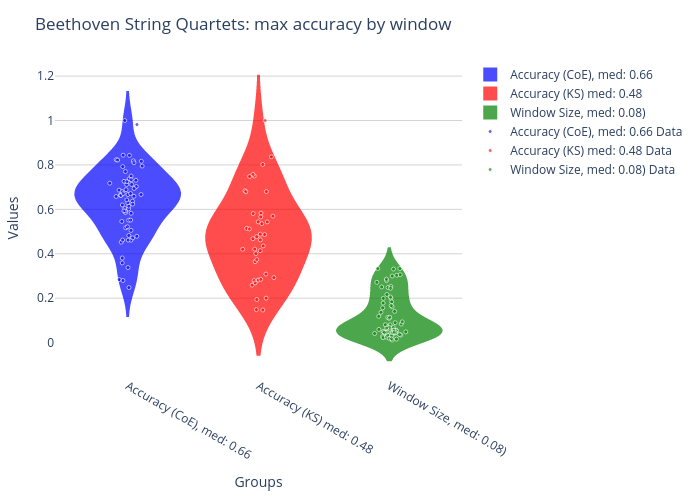

In [30]:
fig = srt.plot_violin_scatter(bee_accs, ks_bee_accs, bee_ws, title="Beethoven String Quartets: max accuracy by window", labels=["Accuracy (CoE), med: $(round(median(bee_accs), digits=2))", "Accuracy (KS) med: $(round(median(ks_bee_accs), digits=2))", "Window Size, med: $(round(median(bee_ws), digits=2)))"])

In [31]:
PlotlyJS.savefig(fig, "beethoven_key_accuracy_by_window.png")

"beethoven_key_accuracy_by_window.png"

In [13]:
f_key = zeros(Float64, length(bee_dfs))
s_key = zeros(Float64, length(bee_dfs))
t_key = zeros(Float64, length(bee_dfs))
e_counts = zeros(Int, length(bee_dfs))
for mp in good_ix
    try
        piece_measures = groupby(bee_dfs[mp], :Measure)
        grouped_ann = groupby(bee_piece_ann[mp], :mc)
        f_key[mp], s_key[mp], t_key[mp], e_counts[mp] = get_key_accuracy(bee_piece_ann[mp], bee_dfs[mp])
    catch e
        println("Error processing piece $mp: $e")
    end
end


Measure 173: Not found in key_guess.
Measure 210: Not found in key_guess.
Measure 82: Not found in key_guess.
Measure 147: Not found in key_guess.
Measure 214: Not found in key_guess.
Measure 221: Not found in key_guess.
Measure 284: Not found in key_guess.
Measure 197: Not found in key_guess.
Measure 2: Not found in key_guess.
Measure 466: Not found in key_guess.
Measure 464: Not found in key_guess.
Measure 348: Not found in key_guess.
Measure 204: Not found in key_guess.


In [14]:
good_ix =findall(x-> x==0, e_counts);

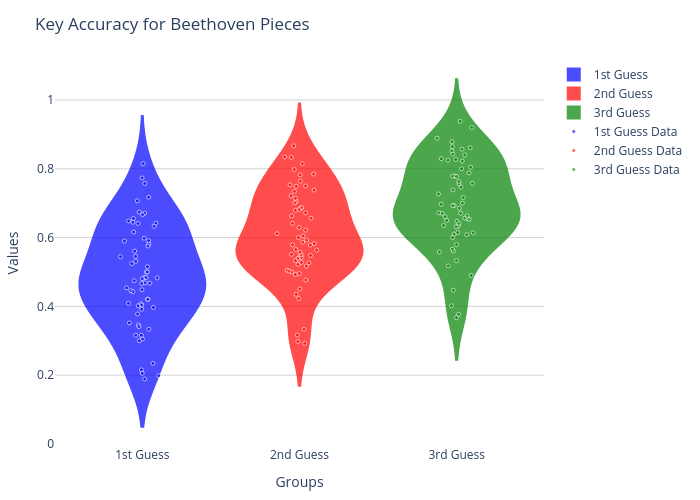

In [15]:
fig = plot_violin_scatter(f_key[good_ix], s_key[good_ix], t_key[good_ix], title="Key Accuracy for Beethoven Pieces", labels=["1st Guess", "2nd Guess", "3rd Guess"])

In [18]:
PlotlyJS.savefig(fig, "beethoven_key_accuracy.html")

"beethoven_key_accuracy.html"

In [41]:
ix = 1
df_calc = copy(moz_dfs[perr_ix[ix]])
df_ann = copy(moz_piece_ann[perr_ix[ix]])
piece_measures = groupby(df_calc, :Measure)
grouped_ann = groupby(df_ann, :mc);
pw = srt.get_oswindows(df_calc, 20, 19)
p_keys = Vector{String}(undef, length(pw))
for i in 1:length(pw)
    p_keys[i] = msr2.get_distance_to_keys(msr2.get_center_effect(Matrix(pw[i])))[1, 1]
end
piece_key = msr2.get_rank_freq(p_keys)[1, 1]
key_ann = Dict{Int,Vector{String}}()
for i in 1:length(grouped_ann)
    keys = vcat(convert(Vector{String}, collect(skipmissing(grouped_ann[i][!, :numeral]))), convert(Vector{String}, grouped_ann[i][!, :localkey]))
    num_me = grouped_ann[i][1, :mn]
    key_ann[num_me] = keys
end
key_guess = Dict{Int,Vector{String}}()
for i in 1:length(piece_measures)
    nm = piece_measures[i][1, :Measure]
    k_m = msr2.get_distance_to_keys(msr2.get_center_effect(Matrix(piece_measures[i])))[1:3, 1]
    key_guess[nm] = msr2.funhar_seq(k_m, piece_key)
end

In [42]:
for key in keys(key_ann)
    try
        key_guess[key]
    catch
        println("Measure $key: Not found in key_guess.")
    end
end

Measure 0: Not found in key_guess.


In [1]:
"""
Krumhansl-Schmuckler Key-Finding Algorithm Implementation
"""

using Statistics

# Key profiles from Krumhansl & Kessler (1982)
const MAJOR_PROFILE = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
const MINOR_PROFILE = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]

# Key names in chromatic order (pitch class 0-11)
const MAJOR_KEY_NAMES = ["C", "Db/C#", "D", "Eb", "E", "F", "Gb/F#", "G", "Ab", "A", "Bb", "B/Cb"]
const MINOR_KEY_NAMES = ["c", "c#", "d", "eb", "e", "f", "f#", "g", "g#/ab", "a", "bb", "b"]

"""
    krumhansl_schmuckler(midi_notes::Vector{Int}; sorted::Bool=false) -> NamedTuple

Find musical key from MIDI note numbers with equal weighting.

# Arguments
- `midi_notes::Vector{Int}`: Array of MIDI note numbers (0-127)
- `sorted::Bool=false`: If true, sort results by correlation (highest to lowest)

# Returns
NamedTuple containing:
- `correlations`: Array of (key, correlation) tuples for all 24 keys
- `best_key`: Most likely key name
- `best_correlation`: Correlation value of best key
- `pitch_class_distribution`: The computed pitch class vector
"""
function krumhansl_schmuckler(midi_notes::Vector{Int}; sorted::Bool=false)
    pitch_class_counts = zeros(Float64, 12)
    for note in midi_notes
        pitch_class = mod(note, 12)
        pitch_class_counts[pitch_class+1] += 1.0
    end

    return _compute_key_correlations(pitch_class_counts, sorted)
end

"""
    krumhansl_schmuckler(midi_notes::Vector{Int}, weights::Vector{<:Real}; sorted::Bool=false) -> NamedTuple

Find musical key from MIDI notes with associated weights.

# Arguments
- `midi_notes::Vector{Int}`: Array of MIDI note numbers (0-127)
- `weights::Vector{<:Real}`: Array of weights (same length as midi_notes)
- `sorted::Bool=false`: If true, sort results by correlation (highest to lowest)

# Returns
Same as unweighted version.
"""
function krumhansl_schmuckler(midi_notes::Vector{Int}, weights::Vector{<:Real}; sorted::Bool=false)
    if length(midi_notes) != length(weights)
        throw(ArgumentError("midi_notes and weights must have the same length"))
    end

    pitch_class_counts = zeros(Float64, 12)
    for (note, weight) in zip(midi_notes, weights)
        pitch_class = mod(note, 12)
        pitch_class_counts[pitch_class+1] += Float64(weight)
    end

    return _compute_key_correlations(pitch_class_counts, sorted)
end

"""
    _compute_key_correlations(pitch_class_counts::Vector{Float64}, sorted::Bool) -> NamedTuple

Internal function to compute correlations for all 24 keys.
"""
function _compute_key_correlations(pitch_class_counts::Vector{Float64}, sorted::Bool)
    correlations = []

    # Calculate correlations for all keys in chromatic order
    for pitch_class in 0:11
        idx = pitch_class + 1

        # Major key
        shifted_profile = circshift(MAJOR_PROFILE, pitch_class)
        corr_major = cor(pitch_class_counts, shifted_profile)
        push!(correlations, (key=MAJOR_KEY_NAMES[idx], correlation=corr_major))

        # Minor key
        shifted_profile = circshift(MINOR_PROFILE, pitch_class)
        corr_minor = cor(pitch_class_counts, shifted_profile)
        push!(correlations, (key=MINOR_KEY_NAMES[idx], correlation=corr_minor))
    end

    # Sort if requested
    if sorted
        correlations = sort(correlations, by=x -> x.correlation, rev=true)
    end

    # Find best key
    best = argmax([c.correlation for c in correlations])

    return (
        correlations=correlations,
        best_key=correlations[best].key,
        best_correlation=correlations[best].correlation,
        pitch_class_distribution=pitch_class_counts
    )
end

_compute_key_correlations